# 02 — Toy CNN Model for Corruption Benchmarking

This notebook defines a lightweight CNN, trains it on the Brain Tumor MRI dataset, and provides utilities to corrupt a configurable fraction of training data so we can measure the impact on clean and corrupted test performance.

## 1. Imports & Setup

In [2]:
import sys
from pathlib import Path

# Allow imports from src/
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from preprocessing import (
    BrainTumorDataset,
    CLASS_NAMES,
    CLASS_TO_IDX,
    IMAGE_SIZE,
    get_dataloaders,
    get_transform,
    load_split,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Toy CNN Architecture

A small 3-block CNN (Conv → BN → ReLU → MaxPool) followed by a classifier head. This is intentionally simple so experiments run quickly.

In [3]:
class ToyCNN(nn.Module):
    """
    Lightweight CNN for 4-class brain tumor classification.

    Architecture:
        3 conv blocks (each: Conv2d -> BatchNorm -> ReLU -> MaxPool)
        Global Average Pooling
        FC classifier
    """

    def __init__(self, num_classes=4, in_channels=3):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 3 -> 32 channels, 224 -> 112
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 32 -> 64 channels, 112 -> 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 64 -> 128 channels, 56 -> 28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Quick sanity check
model = ToyCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
out = model(dummy)
print(f"Model output shape: {out.shape}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: torch.Size([2, 4])
Total parameters: 94,212


## 3. Corruption Utilities

Functions to corrupt a fraction of the training data. The corrupted images are generated by applying a corruption function (e.g., JPEG compression, Gaussian noise) to clean images.

In [4]:
import io
from PIL import Image, ImageFilter


def corrupt_jpeg(image: Image.Image, quality: int = 10) -> Image.Image:
    """Apply heavy JPEG compression to an image."""
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).copy()


def corrupt_gaussian_noise(image: Image.Image, std: float = 25.0) -> Image.Image:
    """Add Gaussian noise to an image."""
    arr = np.array(image, dtype=np.float32)
    noise = np.random.normal(0, std, arr.shape).astype(np.float32)
    noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)


def corrupt_gaussian_blur(image: Image.Image, radius: int = 4) -> Image.Image:
    """Apply Gaussian blur to an image."""
    return image.filter(ImageFilter.GaussianBlur(radius=radius))


# Registry of available corruptions
CORRUPTIONS = {
    "jpeg": corrupt_jpeg,
    "gaussian_noise": corrupt_gaussian_noise,
    "gaussian_blur": corrupt_gaussian_blur,
}

print(f"Available corruptions: {list(CORRUPTIONS.keys())}")

Available corruptions: ['jpeg', 'gaussian_noise', 'gaussian_blur']


## 4. Corrupted Dataset Wrapper

A dataset class that wraps the original dataset and applies corruption to a random subset of samples.

In [5]:
class CorruptedBrainTumorDataset(BrainTumorDataset):
    """
    Extends BrainTumorDataset to corrupt a configurable fraction of samples.

    Parameters
    ----------
    samples : list of (path, label)
    transform : torchvision transform
    corruption_fn : callable (PIL.Image -> PIL.Image)
    corruption_fraction : float in [0, 1]
        Fraction of *training* samples that will be corrupted.
    seed : int
        Random seed for selecting which samples to corrupt (reproducibility).
    """

    def __init__(self, samples, transform, corruption_fn, corruption_fraction=0.0, seed=42):
        super().__init__(samples, transform)
        self.corruption_fn = corruption_fn
        self.corruption_fraction = corruption_fraction

        # Determine which indices will be corrupted
        n_corrupt = int(len(samples) * corruption_fraction)
        rng = random.Random(seed)
        all_indices = list(range(len(samples)))
        rng.shuffle(all_indices)
        self.corrupted_indices = set(all_indices[:n_corrupt])
        print(f"  Corrupting {n_corrupt}/{len(samples)} samples ({corruption_fraction*100:.1f}%)")

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")

        # Apply corruption BEFORE the standard transform
        if idx in self.corrupted_indices:
            image = self.corruption_fn(image)

        if self.transform is not None:
            image = self.transform(image)

        return image, label


def build_corrupted_dataloader(
    split="train",
    corruption_name="jpeg",
    corruption_fraction=0.0,
    batch_size=32,
    num_workers=0,
):
    """
    Build a DataLoader with a specified corruption fraction.
    """
    samples = load_split(split)
    transform = get_transform(split)
    corruption_fn = CORRUPTIONS[corruption_name]

    dataset = CorruptedBrainTumorDataset(
        samples=samples,
        transform=transform,
        corruption_fn=corruption_fn,
        corruption_fraction=corruption_fraction,
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=(split == "train"),
        num_workers=num_workers,
    )

## 5. Training & Evaluation Loops

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns average loss and accuracy."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total

## 6. Full Training Run Function

In [7]:
def run_experiment(
    corruption_name="jpeg",
    corruption_fraction=0.0,
    num_epochs=10,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4,
    device=DEVICE,
):
    """
    Train a fresh ToyCNN with a given corruption fraction and return metrics.

    Returns
    -------
    dict with keys: train_acc, val_acc, history (list of per-epoch dicts)
    """
    print(f"\n{'='*60}")
    print(f"Experiment: corruption={corruption_name}, fraction={corruption_fraction:.0%}")
    print(f"{'='*60}")

    # Build data loaders
    train_loader = build_corrupted_dataloader(
        split="train",
        corruption_name=corruption_name,
        corruption_fraction=corruption_fraction,
        batch_size=batch_size,
    )
    val_loader = build_corrupted_dataloader(
        split="val",
        corruption_name=corruption_name,
        corruption_fraction=0.0,  # Always evaluate on clean data
        batch_size=batch_size,
    )

    # Fresh model
    model = ToyCNN(num_classes=len(CLASS_NAMES)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = []
    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        if epoch % 2 == 0 or epoch == num_epochs:
            print(f"  Epoch {epoch:>3}/{num_epochs} — "
                  f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.3f} | "
                  f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.3f} | "
                  f"{elapsed:.1f}s")

    print(f"  Best val accuracy: {best_val_acc:.4f}")

    return {
        "corruption_name": corruption_name,
        "corruption_fraction": corruption_fraction,
        "best_val_acc": best_val_acc,
        "history": history,
        "model_state": best_model_state,
    }

## 7. Benchmark: Sweep Over Corruption Fractions

Train the model at several corruption fractions (0%, 10%, 25%, 50%, 75%, 100%) and compare validation accuracy.

In [8]:
FRACTIONS = [0.0, 0.10, 0.25, 0.50, 0.75, 1.0]
CORRUPTION = "jpeg"  # Change to "gaussian_noise" or "gaussian_blur" to try others
NUM_EPOCHS = 10  # Increase for better convergence at the cost of runtime

results = []
for frac in FRACTIONS:
    res = run_experiment(
        corruption_name=CORRUPTION,
        corruption_fraction=frac,
        num_epochs=NUM_EPOCHS,
        batch_size=32,
    )
    results.append(res)

print("\n\nDone! Summary:")
print(f"{'Fraction':<12} {'Best Val Acc':<14}")
print("-" * 26)
for r in results:
    print(f"{r['corruption_fraction']:<12.0%} {r['best_val_acc']:<14.4f}")


Experiment: corruption=jpeg, fraction=0%
  Corrupting 0/4480 samples (0.0%)
  Corrupting 0/1120 samples (0.0%)
  Epoch   2/10 — train_loss: 0.7934, train_acc: 0.693 | val_loss: 0.7513, val_acc: 0.667 | 22.4s
  Epoch   4/10 — train_loss: 0.6878, train_acc: 0.734 | val_loss: 0.6208, val_acc: 0.777 | 22.7s
  Epoch   6/10 — train_loss: 0.6222, train_acc: 0.761 | val_loss: 0.6519, val_acc: 0.787 | 22.8s
  Epoch   8/10 — train_loss: 0.5695, train_acc: 0.788 | val_loss: 0.5888, val_acc: 0.720 | 22.8s
  Epoch  10/10 — train_loss: 0.5266, train_acc: 0.802 | val_loss: 0.4680, val_acc: 0.851 | 22.8s
  Best val accuracy: 0.8509

Experiment: corruption=jpeg, fraction=10%
  Corrupting 448/4480 samples (10.0%)
  Corrupting 0/1120 samples (0.0%)
  Epoch   2/10 — train_loss: 0.7812, train_acc: 0.703 | val_loss: 0.7126, val_acc: 0.754 | 23.8s
  Epoch   4/10 — train_loss: 0.6710, train_acc: 0.747 | val_loss: 1.2071, val_acc: 0.478 | 23.8s
  Epoch   6/10 — train_loss: 0.6098, train_acc: 0.771 | val_loss:

## 8. Visualize Results

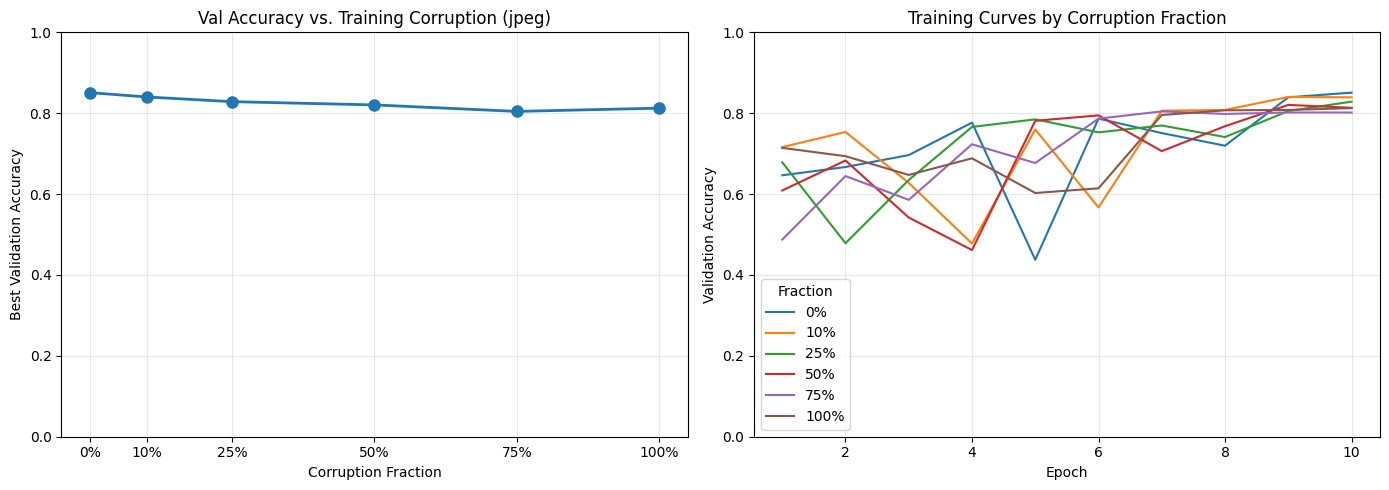

Plot saved to notebooks/02_corruption_sweep.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Best val accuracy vs corruption fraction
fracs = [r["corruption_fraction"] for r in results]
val_accs = [r["best_val_acc"] for r in results]

axes[0].plot(fracs, val_accs, "o-", linewidth=2, markersize=8)
axes[0].set_xlabel("Corruption Fraction")
axes[0].set_ylabel("Best Validation Accuracy")
axes[0].set_title(f"Val Accuracy vs. Training Corruption ({CORRUPTION})")
axes[0].set_xticks(fracs)
axes[0].set_xticklabels([f"{f:.0%}" for f in fracs])
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Plot 2: Training curves for each fraction
for r in results:
    epochs = [h["epoch"] for h in r["history"]]
    vaccs = [h["val_acc"] for h in r["history"]]
    axes[1].plot(epochs, vaccs, label=f"{r['corruption_fraction']:.0%}")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Training Curves by Corruption Fraction")
axes[1].legend(title="Fraction")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "02_corruption_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to notebooks/02_corruption_sweep.png")

## 9. Evaluate Best Model on Corrupted Test Set

For the best-performing corruption fraction, evaluate on both **clean** and **corrupted** test data to measure the robustness trade-off.

In [10]:
# Find the best experiment result
best_result = max(results, key=lambda r: r["best_val_acc"])
print(f"Best model trained with corruption_fraction={best_result['corruption_fraction']:.0%}")
print(f"  Val accuracy: {best_result['best_val_acc']:.4f}")

# Load the best model
best_model = ToyCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
best_model.load_state_dict(best_result["model_state"])

criterion = nn.CrossEntropyLoss()

# Clean test set
clean_test_loader = build_corrupted_dataloader(
    split="test", corruption_name=CORRUPTION, corruption_fraction=0.0, batch_size=32
)
clean_loss, clean_acc = evaluate(best_model, clean_test_loader, criterion, DEVICE)
print(f"\n  Clean test accuracy:     {clean_acc:.4f}")

# Fully corrupted test set
corrupted_test_loader = build_corrupted_dataloader(
    split="test", corruption_name=CORRUPTION, corruption_fraction=1.0, batch_size=32
)
corrupt_loss, corrupt_acc = evaluate(best_model, corrupted_test_loader, criterion, DEVICE)
print(f"  Corrupted test accuracy: {corrupt_acc:.4f}")
print(f"  Robustness gap:          {clean_acc - corrupt_acc:.4f}")

Best model trained with corruption_fraction=0%
  Val accuracy: 0.8509
  Corrupting 0/1600 samples (0.0%)

  Clean test accuracy:     0.7531
  Corrupting 1600/1600 samples (100.0%)
  Corrupted test accuracy: 0.7344
  Robustness gap:          0.0188


## 10. Next Steps

- Try other corruption types (`gaussian_noise`, `gaussian_blur`) or add MRI-specific ones (Gibbs ringing, motion ghosting)
- Increase `NUM_EPOCHS` for more stable convergence
- Evaluate per-class accuracy to check if corruption disproportionately affects specific tumor types
- Add a confusion matrix visualization
- Compare against a pretrained backbone (e.g., ResNet-18) to see if the effect scales